## Project Responsible AI Part 1
#### Topic: Applying Differential Privacy on Input Data and Model.

By:
* Hamza Khalid 24PGAI0079
* Soham Sanyal 24PGAI0055
* Kishnu Shrivastava 24PGAI0042

Note: this notebook has been coded using code references from:
* https://github.com/srayagarwal/JIO_RAI/
* ChatGPT


We have to first encode the categorical data:

In [7]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load your dataset
df_normal = pd.read_csv('ibm_hr_data.csv')

# Initialize LabelEncoder
label_encoders = {}

# Encode categorical columns
for col in df_normal.columns:
    if df_normal[col].dtype == 'object':
        label_encoders[col] = LabelEncoder()
        df_normal[col] = label_encoders[col].fit_transform(df_normal[col])

# Save the encoded dataset to a new CSV file
df_normal.to_csv('ibm_hr_data_encoded.csv', index=False)
df_normal.head()

C:\Users\User\AppData\Local\Temp\ipykernel_4108\2760007430.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


Finding the important features for building the model:

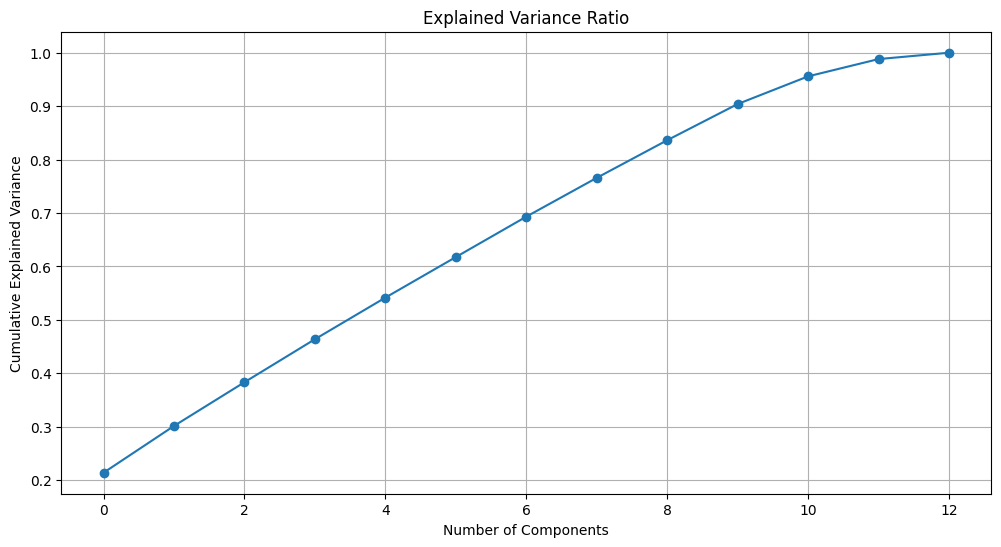

Component 1: TotalWorkingYears
Component 2: MaritalStatus
Component 3: DistanceFromHome
Component 4: DailyRate
Component 5: PercentSalaryHike
Component 6: MonthlyRate
Component 7: EducationField
Component 8: JobRole
Component 9: Gender
Component 10: MaritalStatus
Component 11: Age
Component 12: MonthlyIncome
Component 13: TotalWorkingYears


In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

df_encoded = pd.read_csv('ibm_hr_data_encoded.csv')

# Assuming 'data' is your DataFrame with the selected_features
selected_features = ['MonthlyRate', 'DailyRate', 'MonthlyIncome', 'HourlyRate', 'PercentSalaryHike',
                     'DistanceFromHome', 'Age', 'TotalWorkingYears', 'YearsAtCompany', 'JobRole',
                     'Gender', 'MaritalStatus', 'EducationField']

# Selecting the features from the dataset
X = df_encoded[selected_features]

# Standardizing the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applying PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plotting the explained variance ratio
plt.figure(figsize=(12, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance Ratio')
plt.grid(True)
plt.show()

# Get the most important features for each component
num_top_features = 1  # Number of top features to show for each component
top_features = []
for component in pca.components_:
    top_feature_indices = np.argsort(np.abs(component))[-num_top_features:]
    top_features.append([selected_features[i] for i in top_feature_indices])

# Print the top features for each component
for i, features in enumerate(top_features):
    print(f"Component {i+1}: {', '.join(features)}")


In [9]:
# a function to nicely evaluate all the metrics:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

from sklearn import metrics



def evaluate(model, X_test, y_test, *args):
    
    if args:
        for arg in args:
            print("#### value of epsilon : {arg} ####".format(arg=arg))
            y_pred = model.predict(X_test)
            
            # Classification Report
            print("Classification Report:")
            print(classification_report(y_test, y_pred))
            
            # AUC
            y_pred_proba = model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_pred_proba)
            print(f"AUC: {auc:.4f}")

            # Confusion matrix
            print("\nConfusion Matrix:")
            confusion_matrix = metrics.confusion_matrix(y_test, y_pred)
            cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=[False, True])
            cm_display.plot()
            plt.show()

            # F1 Score
            f1 = f1_score(y_test, y_pred)
            print(f"F1 Score: {f1:.4f}")

            # True Positive Rate (Recall)
            recall = recall_score(y_test, y_pred)
            print(f"True Positive Rate (Recall): {recall:.4f}")

            # True Negative Rate
            tnr = confusion_matrix[0, 0] / (confusion_matrix[0, 0] + confusion_matrix[0, 1])
            print(f"True Negative Rate (TNR): {tnr:.4f}")

            # False Positive Rate
            fpr = confusion_matrix[0, 1] / (confusion_matrix[0, 0] + confusion_matrix[0, 1])
            print(f"False Positive Rate (FPR): {fpr:.4f}")

            epsilon = arg
            accuracy = accuracy_score(y_test, y_pred)
            return epsilon, accuracy
        
    else:
        
        y_pred = model.predict(X_test)
        
        # Classification Report
        print("Classification Report:")
        print(classification_report(y_test, y_pred))
        
        # AUC
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"AUC: {auc:.4f}")

        # Confusion matrix
        print("\nConfusion Matrix:")
        confusion_matrix = metrics.confusion_matrix(y_test, y_pred)
        cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=[False, True])
        cm_display.plot()
        plt.show()

        # F1 Score
        f1 = f1_score(y_test, y_pred)
        print(f"F1 Score: {f1:.4f}")

        # True Positive Rate (Recall)
        recall = recall_score(y_test, y_pred)
        print(f"True Positive Rate (Recall): {recall:.4f}")

        # True Negative Rate
        tnr = confusion_matrix[0, 0] / (confusion_matrix[0, 0] + confusion_matrix[0, 1])
        print(f"True Negative Rate (TNR): {tnr:.4f}")

        # False Positive Rate
        fpr = confusion_matrix[0, 1] / (confusion_matrix[0, 0] + confusion_matrix[0, 1])
        print(f"False Positive Rate (FPR): {fpr:.4f}")

        
        
        
        
    # ROC curve and AUC
    # y_pred_proba = model.predict_proba(X_test)[:, 1]
    # fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    # auc = roc_auc_score(y_test, y_pred_proba)

    # plt.figure(figsize=(8, 6))
    # plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
    # plt.plot([0, 1], [0, 1], linestyle='--', label='No Skill')
    # plt.xlabel('False Positive Rate')
    # plt.ylabel('True Positive Rate')
    # plt.title('ROC Curve')
    # plt.legend()
    # plt.show()




### Now let's make a version of this classifier that applies diffrential privacy by simply updating the coefficients of the model b y adding some noise..

### Diffential Privacy in: Model-> With DP , Input Data-> Without DP

In [10]:
%pip install diffprivlib

You should consider upgrading via the 'c:\Users\User\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [11]:
import diffprivlib

# List all functions and attributes in the module
functions_in_diffprivlib = dir(diffprivlib.models)

# Print the list
print(functions_in_diffprivlib)


['DecisionTreeClassifier', 'GaussianNB', 'KMeans', 'LinearRegression', 'LogisticRegression', 'PCA', 'RandomForestClassifier', 'StandardScaler', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'forest', 'k_means', 'linear_regression', 'logistic_regression', 'naive_bayes', 'pca', 'standard_scaler', 'utils']


In [12]:
# import diffprivlib
# # from diffprivlib.models import RandomForestClassifier as RFC_dp
# from diffprivlib.models import LogisticRegression as LR_dp
# from numpy import arange
# from sklearn.model_selection import train_test_split

# X = df_encoded[selected_features]
# y = df_encoded['Attrition']  # Assuming 'Attrition' is the target variable

# # Splitting the dataset into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

# # Create a differentially private RandomForestClassifier
# # Standardize the features
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # Balance the classes manually
# class_counts = y_train.value_counts()
# class_weights = {0: len(y_train) / (2 * class_counts[0]), 1: len(y_train) / (2 * class_counts[1])}

# for epsilon in arange(0.1, 1.0, 0.1):
#     model_DP_data_normal = RFC_dp(n_estimators=100, random_state=30,  epsilon=epsilon, n_jobs=1, verbose=0, accountant=None)
#     model_DP_data_normal.fit(X_train, y_train)

#     # Evaluate the model
#     evaluate(model_DP_data_normal, X_test, y_test, epsilon)



#### value of epsilon : 0.1 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.75      0.77       236
           1       0.20      0.26      0.23        58

    accuracy                           0.65       294
   macro avg       0.50      0.50      0.50       294
weighted avg       0.68      0.65      0.67       294

AUC: 0.5420

Confusion Matrix:


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\logistic_regression.py:239: PrivacyLeakWarning: Data norm has not been specified and will be calculated on the data provided.  This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify `data_norm` at initialisation.
  warnings.warn("Data norm has not been specified and will be calculated on the data provided.  This will "


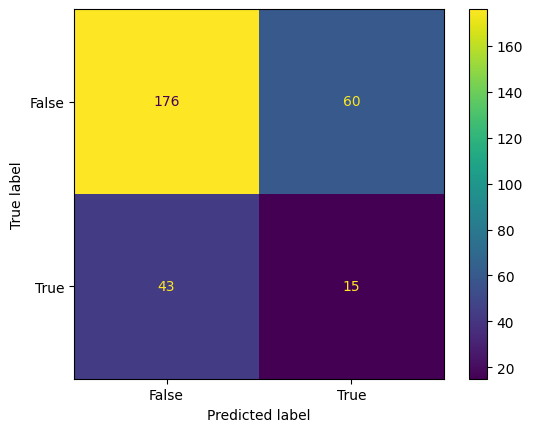

F1 Score: 0.2256
True Positive Rate (Recall): 0.2586
True Negative Rate (TNR): 0.7458
False Positive Rate (FPR): 0.2542
#### value of epsilon : 0.2 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.41      0.53       236
           1       0.17      0.50      0.26        58

    accuracy                           0.43       294
   macro avg       0.47      0.45      0.39       294
weighted avg       0.65      0.43      0.48       294

AUC: 0.4482

Confusion Matrix:


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\logistic_regression.py:239: PrivacyLeakWarning: Data norm has not been specified and will be calculated on the data provided.  This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify `data_norm` at initialisation.
  warnings.warn("Data norm has not been specified and will be calculated on the data provided.  This will "


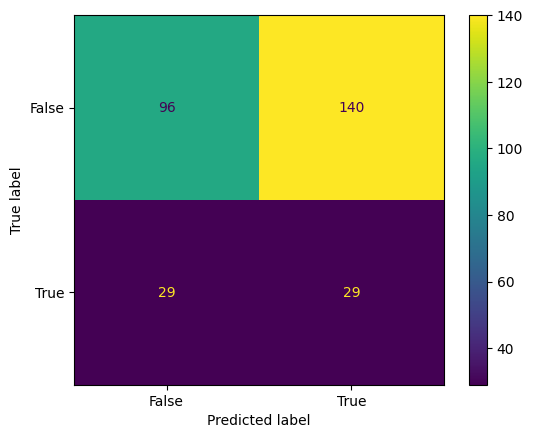

F1 Score: 0.2555
True Positive Rate (Recall): 0.5000
True Negative Rate (TNR): 0.4068
False Positive Rate (FPR): 0.5932
#### value of epsilon : 0.30000000000000004 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.39      0.53       236
           1       0.22      0.71      0.34        58

    accuracy                           0.45       294
   macro avg       0.53      0.55      0.44       294
weighted avg       0.72      0.45      0.49       294

AUC: 0.5590

Confusion Matrix:


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\logistic_regression.py:239: PrivacyLeakWarning: Data norm has not been specified and will be calculated on the data provided.  This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify `data_norm` at initialisation.
  warnings.warn("Data norm has not been specified and will be calculated on the data provided.  This will "


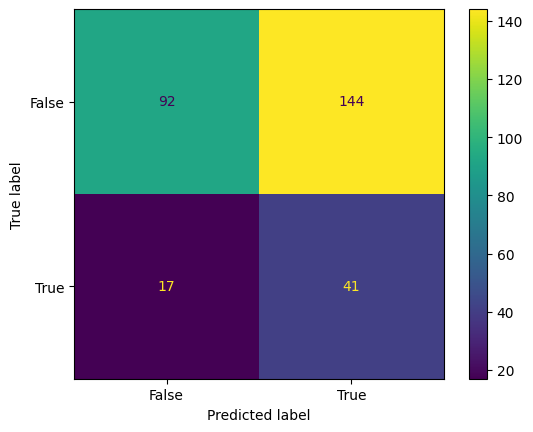

F1 Score: 0.3374
True Positive Rate (Recall): 0.7069
True Negative Rate (TNR): 0.3898
False Positive Rate (FPR): 0.6102
#### value of epsilon : 0.4 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.46      0.58       236
           1       0.19      0.53      0.29        58

    accuracy                           0.47       294
   macro avg       0.50      0.50      0.43       294
weighted avg       0.68      0.47      0.52       294

AUC: 0.4885

Confusion Matrix:


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\logistic_regression.py:239: PrivacyLeakWarning: Data norm has not been specified and will be calculated on the data provided.  This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify `data_norm` at initialisation.
  warnings.warn("Data norm has not been specified and will be calculated on the data provided.  This will "


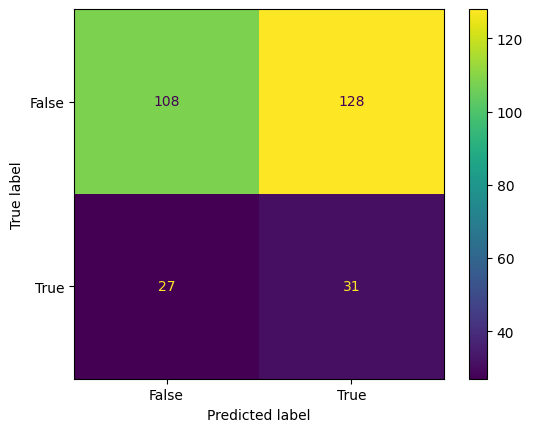

F1 Score: 0.2857
True Positive Rate (Recall): 0.5345
True Negative Rate (TNR): 0.4576
False Positive Rate (FPR): 0.5424
#### value of epsilon : 0.5 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.58      0.67       236
           1       0.16      0.33      0.22        58

    accuracy                           0.53       294
   macro avg       0.47      0.46      0.44       294
weighted avg       0.66      0.53      0.58       294

AUC: 0.4427

Confusion Matrix:


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\logistic_regression.py:239: PrivacyLeakWarning: Data norm has not been specified and will be calculated on the data provided.  This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify `data_norm` at initialisation.
  warnings.warn("Data norm has not been specified and will be calculated on the data provided.  This will "


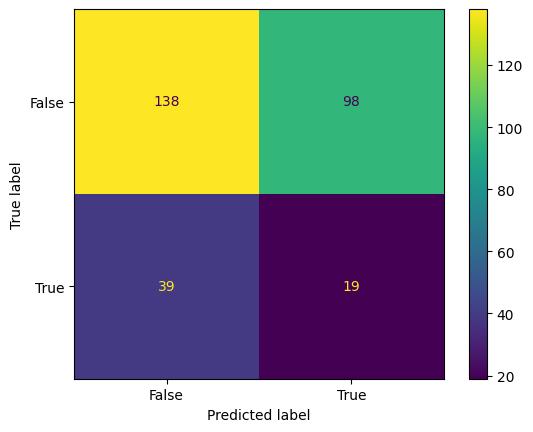

F1 Score: 0.2171
True Positive Rate (Recall): 0.3276
True Negative Rate (TNR): 0.5847
False Positive Rate (FPR): 0.4153
#### value of epsilon : 0.6 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.64      0.72       236
           1       0.25      0.50      0.34        58

    accuracy                           0.61       294
   macro avg       0.55      0.57      0.53       294
weighted avg       0.72      0.61      0.65       294

AUC: 0.6107

Confusion Matrix:


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\logistic_regression.py:239: PrivacyLeakWarning: Data norm has not been specified and will be calculated on the data provided.  This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify `data_norm` at initialisation.
  warnings.warn("Data norm has not been specified and will be calculated on the data provided.  This will "


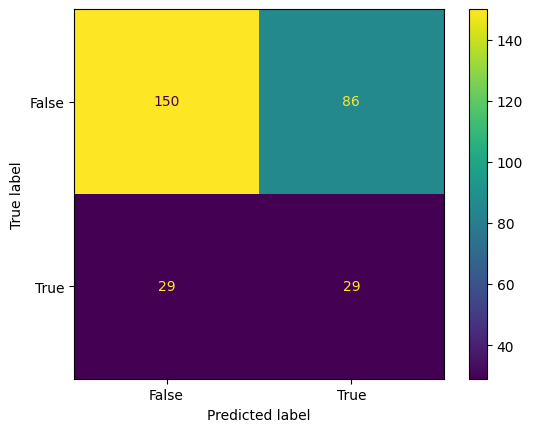

F1 Score: 0.3353
True Positive Rate (Recall): 0.5000
True Negative Rate (TNR): 0.6356
False Positive Rate (FPR): 0.3644
#### value of epsilon : 0.7000000000000001 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.55      0.66       236
           1       0.22      0.52      0.31        58

    accuracy                           0.54       294
   macro avg       0.52      0.53      0.48       294
weighted avg       0.70      0.54      0.59       294

AUC: 0.5489

Confusion Matrix:


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\logistic_regression.py:239: PrivacyLeakWarning: Data norm has not been specified and will be calculated on the data provided.  This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify `data_norm` at initialisation.
  warnings.warn("Data norm has not been specified and will be calculated on the data provided.  This will "


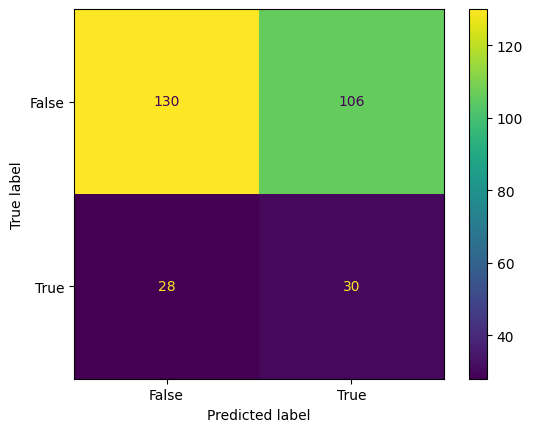

F1 Score: 0.3093
True Positive Rate (Recall): 0.5172
True Negative Rate (TNR): 0.5508
False Positive Rate (FPR): 0.4492
#### value of epsilon : 0.8 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.56      0.65       236
           1       0.15      0.31      0.20        58

    accuracy                           0.51       294
   macro avg       0.46      0.44      0.43       294
weighted avg       0.65      0.51      0.56       294

AUC: 0.3887

Confusion Matrix:


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\logistic_regression.py:239: PrivacyLeakWarning: Data norm has not been specified and will be calculated on the data provided.  This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify `data_norm` at initialisation.
  warnings.warn("Data norm has not been specified and will be calculated on the data provided.  This will "


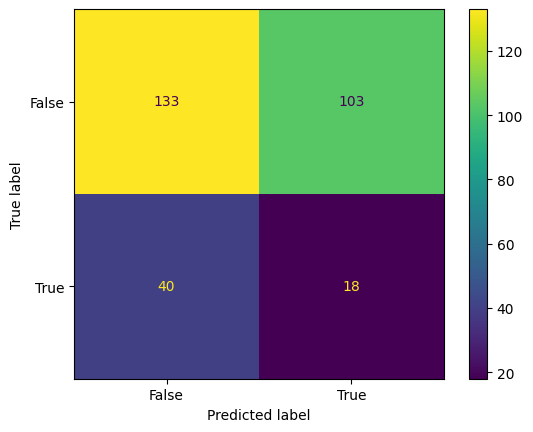

F1 Score: 0.2011
True Positive Rate (Recall): 0.3103
True Negative Rate (TNR): 0.5636
False Positive Rate (FPR): 0.4364
#### value of epsilon : 0.9 ####
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.78      0.78       236
           1       0.15      0.16      0.15        58

    accuracy                           0.65       294
   macro avg       0.47      0.47      0.47       294
weighted avg       0.66      0.65      0.66       294

AUC: 0.4510

Confusion Matrix:


c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\diffprivlib\models\logistic_regression.py:239: PrivacyLeakWarning: Data norm has not been specified and will be calculated on the data provided.  This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify `data_norm` at initialisation.
  warnings.warn("Data norm has not been specified and will be calculated on the data provided.  This will "


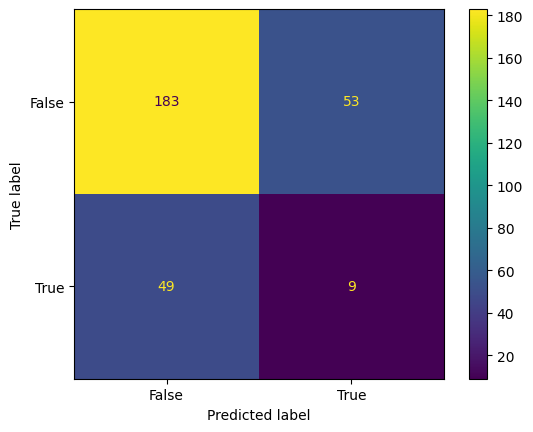

F1 Score: 0.1500
True Positive Rate (Recall): 0.1552
True Negative Rate (TNR): 0.7754
False Positive Rate (FPR): 0.2246


In [13]:
import diffprivlib
from diffprivlib.models import LogisticRegression as LR_dp
from numpy import arange
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_encoded[selected_features]
y = df_encoded['Attrition']  # Assuming 'Attrition' is the target variable

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

# Create a differentially private Logistic Regression
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Balance the classes manually
class_counts = y_train.value_counts()
class_weights = {0: len(y_train) / (2 * class_counts[0]), 1: len(y_train) / (2 * class_counts[1])}

for epsilon in arange(0.1, 1.0, 0.1):
    model_DP_data_normal = LR_dp(epsilon=epsilon)
    model_DP_data_normal.fit(X_train_scaled, y_train)

    # Evaluate the model
    evaluate(model_DP_data_normal, X_test_scaled, y_test, epsilon)
